In [54]:
import pandas as pd
data = pd.read_csv("wine.csv")
y = data['quality']
x = data.drop(['quality'], axis=1)
#data.head()
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.25, random_state=42 )

from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(hidden_layer_sizes=(6,5),
                    random_state=5,
                    verbose=True,
                    learning_rate_init= 0.01)
clf.fit(x_train,y_train)


Iteration 1, loss = 20.11451744
Iteration 2, loss = 10.84787675
Iteration 3, loss = 6.55556444
Iteration 4, loss = 4.62833060
Iteration 5, loss = 2.86952062
Iteration 6, loss = 2.16788956
Iteration 7, loss = 1.79510285
Iteration 8, loss = 1.50643080
Iteration 9, loss = 1.39582257
Iteration 10, loss = 1.33842867
Iteration 11, loss = 1.29943917
Iteration 12, loss = 1.28106199
Iteration 13, loss = 1.25934940
Iteration 14, loss = 1.24133964
Iteration 15, loss = 1.21429778
Iteration 16, loss = 1.20070078
Iteration 17, loss = 1.19438063
Iteration 18, loss = 1.18801833
Iteration 19, loss = 1.18131330
Iteration 20, loss = 1.17645959
Iteration 21, loss = 1.17349410
Iteration 22, loss = 1.16928084
Iteration 23, loss = 1.16661900
Iteration 24, loss = 1.16350493
Iteration 25, loss = 1.16099609
Iteration 26, loss = 1.16113508
Iteration 27, loss = 1.15983841
Iteration 28, loss = 1.15628321
Iteration 29, loss = 1.15961959
Iteration 30, loss = 1.16212186
Iteration 31, loss = 1.16084591
Iteration 32, l

d:\iii\srm\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(6, ...)"
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",5
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200


In [55]:
print(y_train.shape)
print(x_train.shape)
print(y_test.shape)
print(x_test.shape)

(1199,)
(1199, 11)
(400,)
(400, 11)


In [56]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [62]:
from sklearn.neural_network import MLPClassifier 
model=MLPClassifier(hidden_layer_sizes=(64,32),activation='tanh',max_iter=500)
model.fit(x_train,y_train)
print (model.score(x_train,y_train))

0.6472060050041701


In [64]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(64, input_dim=x_train.shape[1], activation='relu'))
model.add(Dense(6, activation='softmax'))
from tensorflow.keras.optimizers import Adam
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])
y_train=y_train-6
y_test=y_test-6
print(np.unique(y_train))
model.summary()


[0 1 2 3 4 5]


d:\iii\srm\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,158 (4.52 KB)

 Trainable params: 1,158 (4.52 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
model.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4223 - loss: 1.6197 - val_accuracy: 0.5333 - val_loss: 1.2025
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4745 - loss: 1.3012 - val_accuracy: 0.5083 - val_loss: 1.1204
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4640 - loss: 1.2965 - val_accuracy: 0.5833 - val_loss: 1.0880
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4943 - loss: 1.2450 - val_accuracy: 0.5375 - val_loss: 1.0412
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4745 - loss: 1.3876 - val_accuracy: 0.5750 - val_loss: 1.1399
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4932 - loss: 1.1846 - val_accuracy: 0.5625 - val_loss: 1.0847
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5026 - loss: 1.1798 - val_accuracy: 0.5917 - val_loss: 1.0402
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5193 - loss: 1.1219 - val_accuracy: 0.5458 - v

In [66]:
pred= model.predict(x_test)
pred=np.argmax(pred,axis=1)
pred=pred+3
print(pred)
model.save("wine_quality_model.h5")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


[5 5 5 5 6 5 5 5 6 6 7 5 6 5 5 7 5 5 7 5 5 5 6 7 5 5 7 5 5 7 5 5 6 5 5 5 7
 6 6 7 5 5 7 5 6 6 7 6 5 6 5 5 5 7 5 5 6 5 6 5 5 6 5 5 7 5 7 5 6 5 7 5 6 6
 6 5 6 5 6 6 5 7 6 5 6 6 5 6 6 5 6 5 6 6 5 6 5 6 5 5 5 5 6 6 6 6 6 5 6 5 6
 5 5 5 6 6 7 5 5 6 6 5 6 5 5 5 6 6 5 6 6 5 5 7 6 5 5 5 5 6 6 6 7 5 6 5 6 5
 6 5 6 7 5 6 6 6 5 6 5 6 7 6 6 5 5 6 5 5 5 5 5 5 7 5 7 6 6 5 5 5 3 7 5 7 5
 6 5 6 7 5 6 6 5 7 6 5 5 5 5 6 5 5 5 5 6 5 5 5 6 5 5 5 6 7 7 6 5 5 6 5 5 6
 6 6 5 5 5 7 5 5 5 5 7 6 7 6 5 6 5 5 5 5 6 6 5 5 6 5 7 5 5 6 5 5 5 5 5 7 6
 6 6 6 5 7 6 7 5 5 6 7 5 6 5 5 5 5 6 6 7 5 7 5 5 5 5 6 5 6 5 6 5 7 6 5 5 6
 5 7 6 7 5 5 6 5 5 5 6 6 7 7 6 5 5 6 5 6 5 5 7 5 5 5 6 5 5 5 6 5 5 7 6 7 5
 5 6 6 6 7 5 5 6 7 6 5 6 5 6 5 5 6 5 7 5 5 5 6 5 5 5 6 6 5 5 6 5 6 6 5 5 5
 5 5 6 6 5 7 5 6 5 5 5 6 7 5 6 6 6 5 5 6 5 6 5 5 6 6 7 5 5 7]


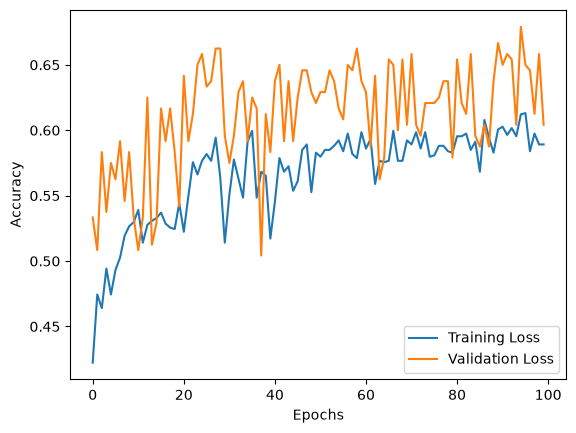

In [67]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['accuracy'], label='Training Loss')
plt.plot(model.history.history['val_accuracy'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [71]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(x_test)
confusion_matrix= confusion_matrix(y_test,y_pred)
print(confusion_matrix)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ValueError: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets

d:\iii\srm\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,158 (4.52 KB)

 Trainable params: 1,158 (4.52 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
print(x_train.shape)

(1199, 11)


In [73]:
print(model.predict(x_test))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
[[1.6770644e-04 2.9686958e-02 5.7706857e-01 3.6678070e-01 2.5933085e-02
  3.6296676e-04]
 [5.2745137e-09 4.2122039e-03 7.4510098e-01 2.4965209e-01 9.6984504e-04
  6.4908701e-05]
 [2.3503932e-03 2.9393647e-02 4.5612839e-01 3.9777374e-01 1.1253845e-01
  1.8154108e-03]
 ...
 [1.0058433e-03 3.3459764e-02 5.0924468e-01 4.1169286e-01 4.4203360e-02
  3.9354849e-04]
 [8.0964208e-04 3.6225222e-02 5.8319509e-01 3.5331419e-01 2.5719736e-02
  7.3608354e-04]
 [5.2767036e-06 2.1612856e-03 1.3356715e-01 4.0575990e-01 4.1100562e-01
  4.7500800e-02]]


In [74]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(64, input_dim=x_train.shape[1], activation='relu'))#aset #[1] for column, with just shape (row, column)input is 11 in dat
model.add(Dense(6, activation='softmax'))#softmax because multiple classes
from tensorflow.keras.optimizers import Adam
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])# regression mse rmse , loss = crossentropy; classification accuracy
y_train = y_train -3 
y_test= y_test -3
print(np.unique(y_train))

[-3 -2 -1  0  1  2]


d:\iii\srm\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
print(np.unique(y_test))

[-3 -2 -1  0  1  2]


In [81]:
pred= model.predict(x_test)
pred=np.argmax(pred,axis=1)
pred=pred+3
print(pred)
model.save("wine_quality_model.h5")

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense_26' is incompatible with the layer: expected axis -1 of input shape to have value 8, but received input with shape (32, 11)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 11), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [82]:
import pandas as pd
bp=pd.read_csv("House_Rent_Dataset.csv")
y=bp['Rent']
x=bp.drop(['Rent','Posted On','Floor','Area Locality'],axis=1)
import category_encoders as ce
encoder=ce.LeaveOneOutEncoder(return_df=True)
X=encoder.fit_transform(x,y)

In [83]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [84]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(32, input_shape=(8,), activation='relu'))
model.add(Dense(1, activation='relu'))
model.compile(optimizer='adam',loss='mean_squared_error', metrics=['mse'])
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)


Epoch 1/100


d:\iii\srm\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7154173440.0000 - mse: 7154173440.0000 - val_loss: 3177533696.0000 - val_mse: 3177533696.0000
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6891483648.0000 - mse: 6891483648.0000 - val_loss: 3081285120.0000 - val_mse: 3081285120.0000
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6822895104.0000 - mse: 6822895104.0000 - val_loss: 3028530176.0000 - val_mse: 3028530176.0000
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6770587136.0000 - mse: 6770587136.0000 - val_loss: 3005353728.0000 - val_mse: 3005353728.0000
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6755643392.0000 - mse: 6755643392.0000 - val_loss: 2966582272.0000 - val_mse: 2966582272.0000
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6719845888.0000 - mse: 6719845888.0000 - val_loss: 2956152320.0000 - val_mse: 2956152320.0000
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6708918784.0000 - mse: 6708918784.0

In [85]:
print(model.history.history)

{'loss': [7154173440.0, 6891483648.0, 6822895104.0, 6770587136.0, 6755643392.0, 6719845888.0, 6708918784.0, 6685637120.0, 6666012160.0, 6652223488.0, 6638103552.0, 6624154624.0, 6613426688.0, 6618385408.0, 6577118208.0, 6574072320.0, 6552843264.0, 6544580096.0, 6518978048.0, 6513564672.0, 6504595968.0, 6469068800.0, 6473090048.0, 6453563392.0, 6434864640.0, 6419948032.0, 6402290688.0, 6379532800.0, 6373854720.0, 6359419904.0, 6350968832.0, 6324511232.0, 6296848896.0, 6281532416.0, 6272966656.0, 6251096064.0, 6231994880.0, 6214805504.0, 6192696320.0, 6173901312.0, 6171268608.0, 6147417088.0, 6129824768.0, 6106536960.0, 6119603712.0, 6072579584.0, 6067721728.0, 6042840576.0, 6037521408.0, 6009241600.0, 6006124544.0, 5973879808.0, 5957502464.0, 5982940160.0, 5936378368.0, 5924284416.0, 5921767424.0, 5885712896.0, 5876560384.0, 5857073152.0, 5849627136.0, 5854966784.0, 5832246784.0, 5805644800.0, 5801016320.0, 5774799872.0, 5769364480.0, 5767513600.0, 5752995328.0, 5746024448.0, 5732515840

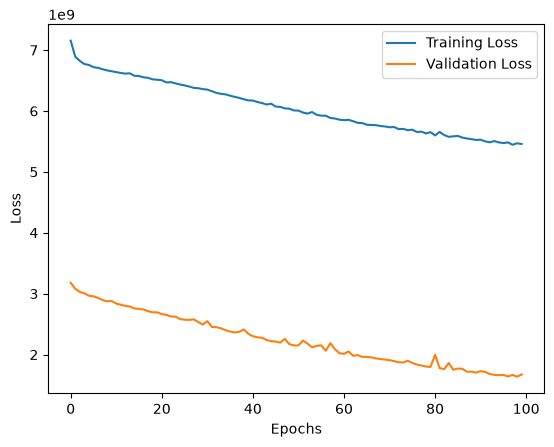

In [86]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

AttributeError: partially initialized module 'torch' from 'd:\iii\srm\Lib\site-packages\torch\__init__.py' has no attribute '_logging' (most likely due to a circular import)